In [54]:
using QuadGK, LaTeXStrings, Plots, LinearAlgebra, BenchmarkTools,StaticArrays;
using DataFrames, CSV,Interpolations,Suppressor,Polynomials;
import JLD,ForwardDiff,NLsolve;
using Plots.PlotMeasures;

In [2]:
gr(frame=:box,size=(400, 300));

In [3]:
const unit = 1.0e-3;
const mpic = 139.57018unit; const mpi0 = 134.9766unit;
const meta = 547.862unit; const mkc = 493.677unit; const mk0 = 497.614unit;
const mpi = (2mpic + mpi0)/3; const mk = (mkc + mk0)/2;
const mπ=mpi;
const mJψ=3.0969;
const metap=0.95778;

In [4]:
# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >= 0 ? sqrt(x + 0im) : -sqrt(x - 0im)
end

# redefine angle so that its cut is along the positive x axis
function xangle(x)
    imag(x) >= 0 ? angle(x + 0im) : angle(x) + 2 * π
end

# redefine log so that its cut is along the positive x axis
function xlog(x)
    imag(x) >= 0 ? log(x + 0im) : log(x) + im * 2 * π
end
λ(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z;

In [5]:
qon(s,m1,m2)=sqrt(s-(m1-m2)^2+0im)*xsqrt(s-(m1+m2)^2)/(2*sqrt(s))

qon (generic function with 1 method)

# N/D parameterization

In [6]:
paras_best_P=[-0.68,-13.12,3.52,-15.43,-67.22,-190.73,1.82,7.64,63.85];
paras_best_D=[5.63,-3.77,1.86,147.79,-33.39,8.06,-2402.56,462.60,-86.60,-614.58,164.72,-42.19];

In [7]:
function Kmatrix_P(s;paras=paras_best_P)
    gηπ,gηpπ,msq,c11,c12,c22,d11,d12,d22=paras
    v11=gηπ^2/(msq-s)+c11+d11*s
    v12=gηπ*gηpπ/(msq-s)+c12+d12*s
    v22=gηpπ^2/(msq-s)+c22+d22*s
    return @SMatrix [[v11 v12];[v12 v22]]
end

function Kmatrix_D(s;paras=paras_best_D)
    gηπ1,gηpπ1,msq1,gηπ2,gηpπ2,msq2,c11,c12,c22,d11,d12,d22=paras
    v11=gηπ1^2/(msq1-s)+gηπ2^2/(msq2-s)+c11+d11*s
    v12=gηπ1*gηpπ1/(msq1-s)+gηπ2*gηpπ2/(msq2-s)+c12+d12*s
    v22=gηpπ1^2/(msq1-s)+gηpπ2^2/(msq2-s)+c22+d22*s
    return @SMatrix [[v11 v12];[v12 v22]]
end

Kmatrix_D (generic function with 1 method)

In [8]:
@btime Kmatrix_P(1.0)

  13.598 ns (2 allocations: 64 bytes)


2×2 SMatrix{2, 2, Float64, 4} with indices SOneTo(2)×SOneTo(2):
 -13.4265  -56.0397
 -56.0397  -58.5727

In [9]:
function ρN(s;J=1,α=2,sL=1.0)
    v11=s<=(mpi+meta)^2 ? 0.0 : (λ(s,meta^2,mpi^2))^(J+1/2)/(s+sL)^(2*J+1+α)
    v22=s<=(mpi+metap)^2 ? 0.0 : (λ(s,metap^2,mpi^2))^(J+1/2)/(s+sL)^(2*J+1+α)
    return @SMatrix [[v11 0.0];[0.0 v22]]
end

ρN (generic function with 1 method)

In [10]:
@btime ρN(1.0)

  0.916 ns (0 allocations: 0 bytes)


2×2 SMatrix{2, 2, Float64, 4} with indices SOneTo(2)×SOneTo(2):
 0.00913941  0.0
 0.0         0.0

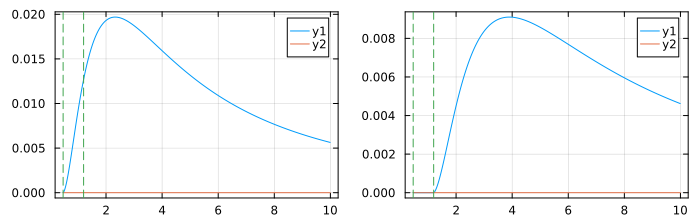

In [11]:
let sv=collect((mpi+meta)^2:0.01:10.0)
    resv=ρN.(sv;J=1)
    plt1=plot(sv,real.([resv[i][1,1] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][1,1] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt2=plot(sv,real.([resv[i][2,2] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][2,2] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plot(plt1,plt2,layout=(1,2),size=(700,220))
end

In [12]:
function Dmatrix_P(s;ϵ=1.0e-8,rtol=1.0e-4)
    invK=inv(Kmatrix_P(s))
    dismat=quadgk(x->(@. s/π*ρN(x;J=1)/x/(x-s-im*ϵ)),(mpi+meta)^2,Inf;rtol=rtol)[1]
    return invK-dismat
end

function Dmatrix_D(s;ϵ=1.0e-8,rtol=1.0e-4)
    invK=inv(Kmatrix_D(s))
    dismat=quadgk(x->(@. s/π*ρN(x;J=2)/x/(x-s-im*ϵ)),(mpi+meta)^2,Inf;rtol=rtol)[1]
    return invK-dismat
end

Dmatrix_D (generic function with 1 method)

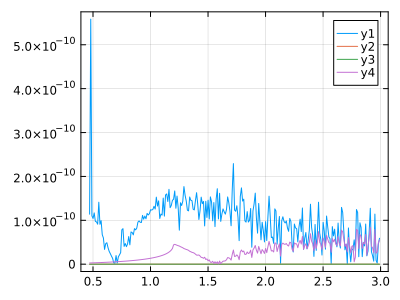

In [13]:
#ensure the imaginary part
let sv=collect((mpi+meta)^2:0.01:3.0)
    diff_v=[imag.(Dmatrix_P(s))+ρN(s;J=1) for s in sv]
    plot(sv,abs.([diff_v[i][1,1] for i in eachindex(sv)]))
    plot!(sv,abs.([diff_v[i][1,2] for i in eachindex(sv)]))
    plot!(sv,abs.([diff_v[i][2,1] for i in eachindex(sv)]))
    plot!(sv,abs.([diff_v[i][2,2] for i in eachindex(sv)]))
end

In [14]:
Dmatrix_P((mpi+meta)^2+0.1),Dmatrix_P((mpi+metap)^2+0.1)

(ComplexF64[0.03724952529513737 - 0.0008453231655784213im -0.027018522689444834 - 0.0im; -0.027018522689444834 - 0.0im 0.005596769626378677 - 3.76949725188272e-12im], ComplexF64[0.00545468739007088 - 0.014149896465565043im -0.02174115335547234 - 0.0im; -0.02174115335547234 - 0.0im 0.001900514967525295 - 0.00024456924943902904im])

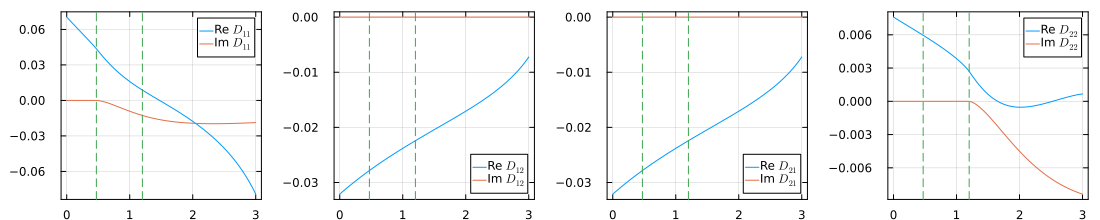

In [15]:
let sv=collect(eps():0.002:3.0)
    resv=Dmatrix_P.(sv)
    plt1=plot(sv,[real(resv[i][1,1]) for i in eachindex(sv)],label=L"Re $D_{11}$")
    plot!(sv,[imag(resv[i][1,1]) for i in eachindex(sv)],label=L"Im $D_{11}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt2=plot(sv,[real(resv[i][1,2]) for i in eachindex(sv)],label=L"Re $D_{12}$")
    plot!(sv,[imag(resv[i][1,2]) for i in eachindex(sv)],label=L"Im $D_{12}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt3=plot(sv,[real(resv[i][2,1]) for i in eachindex(sv)],label=L"Re $D_{21}$")
    plot!(sv,[imag(resv[i][2,1]) for i in eachindex(sv)],label=L"Im $D_{21}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt4=plot(sv,[real(resv[i][2,2]) for i in eachindex(sv)],label=L"Re $D_{22}$")
    plot!(sv,[imag(resv[i][2,2]) for i in eachindex(sv)],label=L"Im $D_{22}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plot(plt1,plt2,plt3,plt4,layout=(1,4),size=(1100,220))
end

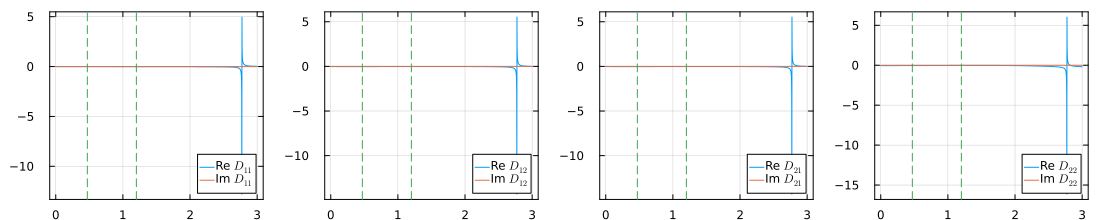

In [16]:
let sv=collect(eps():0.002:3.0)
    resv=Dmatrix_D.(sv)
    plt1=plot(sv,[real(resv[i][1,1]) for i in eachindex(sv)],label=L"Re $D_{11}$")
    plot!(sv,[imag(resv[i][1,1]) for i in eachindex(sv)],label=L"Im $D_{11}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt2=plot(sv,[real(resv[i][1,2]) for i in eachindex(sv)],label=L"Re $D_{12}$")
    plot!(sv,[imag(resv[i][1,2]) for i in eachindex(sv)],label=L"Im $D_{12}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt3=plot(sv,[real(resv[i][2,1]) for i in eachindex(sv)],label=L"Re $D_{21}$")
    plot!(sv,[imag(resv[i][2,1]) for i in eachindex(sv)],label=L"Im $D_{21}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt4=plot(sv,[real(resv[i][2,2]) for i in eachindex(sv)],label=L"Re $D_{22}$")
    plot!(sv,[imag(resv[i][2,2]) for i in eachindex(sv)],label=L"Im $D_{22}$")
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plot(plt1,plt2,plt3,plt4,layout=(1,4),size=(1100,220))
end

In [17]:
ω(s;s0=1.0)=s/(s+s0);

In [18]:
poly_ηπ_P=[408.75,-632.57,281.48,-57.98];
poly_ηπ_D=[-247.80,413.91,-190.94,59.25];
poly_ηpπ_P=[-47.05,65.84,-20.96,1.20];
poly_ηpπ_D=[230.92,-290.66,176.88,-3.82];

In [19]:
n1_ηπ=Polynomials.ChebyshevT(poly_ηπ_P);
n2_ηπ=Polynomials.ChebyshevT(poly_ηπ_D);
n1_ηpπ=Polynomials.ChebyshevT(poly_ηpπ_P);
n2_ηpπ=Polynomials.ChebyshevT(poly_ηpπ_D);

In [20]:
nP_ηπ(s)=n1_ηπ(ω(s))
nD_ηπ(s)=n2_ηπ(ω(s))
nP_ηpπ(s)=n1_ηpπ(ω(s))
nD_ηpπ(s)=n2_ηpπ(ω(s))

nD_ηpπ (generic function with 1 method)

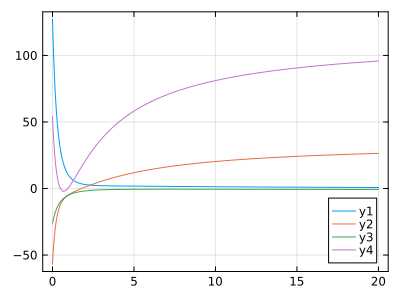

In [21]:
plot(0.0:0.01:20.0,[x->nP_ηπ(x),x->nD_ηπ(x),x->nP_ηpπ(x),x->nD_ηpπ(x)])

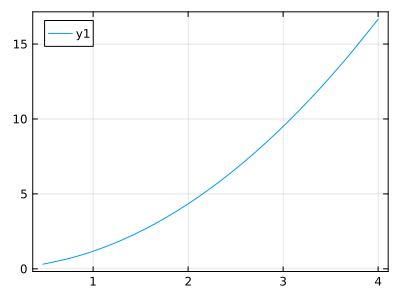

In [22]:
plot(s->λ(s,mpi^2,-0.1),(mpi+meta)^2,4) #ensure the positivity

In [23]:
function amp1(s;J=1,teff=-0.1)
    q=sqrt(λ(s,mpi^2,teff))/(2*sqrt(s))
    pπη,pπηp=qon(s,mpi,meta),qon(s,mpi,metap)
    invD=inv(Dmatrix_P(s))
    res=q^(J-1)*([pπη^J pπηp^J].*([nP_ηπ(s) nP_ηpπ(s)]*invD))
    return res
end

function amp2(s;J=2,teff=-0.1)
    q=sqrt(λ(s,mpi^2,teff))/(2*sqrt(s))
    pπη,pπηp=qon(s,mpi,meta),qon(s,mpi,metap)
    invD=inv(Dmatrix_D(s))
    res=q^(J-1)*([pπη^J pπηp^J].*([nD_ηπ(s) nD_ηpπ(s)]*invD))
    return res
end

amp2 (generic function with 1 method)

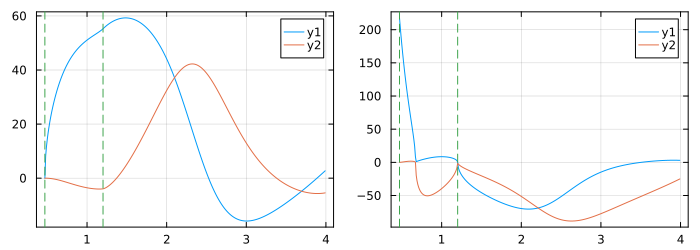

In [24]:
let sv=collect((mpi+meta)^2:0.01:4.0)
    resv=amp1.(sv)
    plt1=plot(sv,real.([resv[i][1] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][1] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt2=plot(sv,real.([resv[i][2] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][2] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plot(plt1,plt2,layout=(1,2),size=(700,250))
end

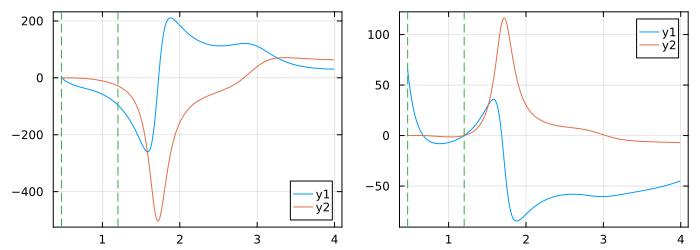

In [25]:
let sv=collect((mpi+meta)^2:0.01:4.0)
    resv=amp2.(sv)
    plt1=plot(sv,real.([resv[i][1] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][1] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plt2=plot(sv,real.([resv[i][2] for i in eachindex(resv)]))
    plot!(sv,imag.([resv[i][2] for i in eachindex(resv)]))
    vline!([(mpi+meta)^2,(mpi+metap)^2],ls=:dash,label=false)
    plot(plt1,plt2,layout=(1,2),size=(700,250))
end

\begin{align}
T^{(n)}(s)=\frac{N(s)}{D(s)+2i\rho^{(n)}N(s)}
\end{align}
with $\rho^{(n)}=\text{diag}\{N_i\rho_i(s)\}$ and $N_i=0(1)$ for (un)physics sheets, see http://arxiv.org/abs/1808.09664.

In [59]:
function Dmatrix_P_rs(s;rs=:00,J=1,α=2,sL=1.0)
    res=zeros(ComplexF64,2,2)
    ρN1=λ(s,meta^2,mpi^2)^J/(s+sL)^(2*J+1+α)*sqrt(s-(meta-mpi)^2+0im)*xsqrt(s-(meta+mpi)^2+0im)
    ρN2=λ(s,metap^2,mpi^2)^J/(s+sL)^(2*J+1+α)*sqrt(s-(metap-mpi)^2+0im)*xsqrt(s-(metap+mpi)^2+0im)
    
    if rs==:00
        res=Dmatrix_P(s)
    elseif rs==:10
        res=Dmatrix_P(s)+[2*im*ρN1 0.0+0.0im;0.0+0.0im 0.0+0.0im]
    elseif rs==:01
        res=Dmatrix_P(s)+[0.0+0.0im 0.0+0.0im;0.0+0.0im 2*im*ρN2]
    elseif rs==:11
        res=Dmatrix_P(s)+[2*im*ρN1 0.0+0.0im;0.0+0.0im 2*im*ρN2]
    end
    return res
end

Dmatrix_P_rs (generic function with 1 method)

In [60]:
function Dmatrix_D_rs(s;rs=:00,J=2,α=2,sL=1.0)
    res=zeros(ComplexF64,2,2)
    ρN1=λ(s,meta^2,mpi^2)^J/(s+sL)^(2*J+1+α)*sqrt(s-(meta-mpi)^2+0im)*xsqrt(s-(meta+mpi)^2+0im)
    ρN2=λ(s,metap^2,mpi^2)^J/(s+sL)^(2*J+1+α)*sqrt(s-(metap-mpi)^2+0im)*xsqrt(s-(metap+mpi)^2+0im)
    
    if rs==:00
        res=Dmatrix_D(s)
    elseif rs==:10
        res=Dmatrix_D(s)+[2*im*ρN1 0.0+0.0im;0.0+0.0im 0.0+0.0im]
    elseif rs==:01
        res=Dmatrix_D(s)+[0.0+0.0im 0.0+0.0im;0.0+0.0im 2*im*ρN2]
    elseif rs==:11
        res=Dmatrix_D(s)+[2*im*ρN1 0.0+0.0im;0.0+0.0im 2*im*ρN2]
    end
    return res
end

Dmatrix_D_rs (generic function with 1 method)

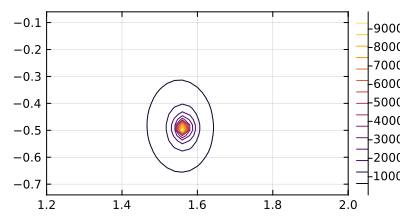

In [72]:
let ReEv=collect(1.2:0.02:2.0),ImEv=collect(-0.74:0.02:-0.05)
    resv=[1/abs(det(Dmatrix_P_rs((x+im*y/2)^2;rs=:11))) for y in ImEv,x in ReEv]
    contour(ReEv,ImEv,resv,size=(400,220)) #,fill=true
end

In [63]:
function poles_Pwave!(F,x)
    m, Γ = x
    tmp = det(Dmatrix_P_rs((m-im*Γ/2)^2;rs=:11))
    F[1] = real(tmp)
    F[2] = imag(tmp)
end

poles_Pwave! (generic function with 1 method)

In [64]:
NLsolve.nlsolve((F, x) -> poles_Pwave!(F, x), [1.564, 0.492])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [1.564, 0.492]
 * Zero: [1.563455082906522, 0.49144336018642804]
 * Inf-norm of residuals: 0.000000
 * Iterations: 1
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 2
 * Jacobian Calls (df/dx): 2

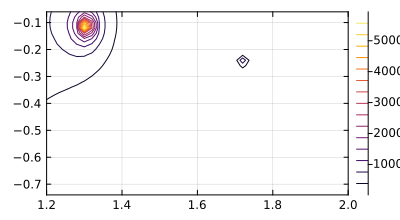

In [65]:
let ReEv=collect(1.2:0.02:2.0),ImEv=collect(-0.74:0.02:-0.05)
    resv=[1/abs(det(Dmatrix_D_rs((x+im*y/2)^2;rs=:11))) for y in ImEv,x in ReEv]
    contour(ReEv,ImEv,resv,size=(400,220)) #,fill=true
end

In [66]:
function poles_Dwave!(F,x)
    m, Γ = x
    tmp = det(Dmatrix_D_rs((m-im*Γ/2)^2;rs=:11))
    F[1] = real(tmp)
    F[2] = imag(tmp)
end

poles_Dwave! (generic function with 1 method)

In [67]:
NLsolve.nlsolve((F, x) -> poles_Dwave!(F, x), [1.306, 0.114])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [1.306, 0.114]
 * Zero: [1.3067644377342498, 0.11286902624357976]
 * Inf-norm of residuals: 0.000000
 * Iterations: 2
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 3
 * Jacobian Calls (df/dx): 3

In [68]:
NLsolve.nlsolve((F, x) -> poles_Dwave!(F, x), [1.722, 0.247])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [1.722, 0.247]
 * Zero: [1.723618709144465, 0.24314024951367566]
 * Inf-norm of residuals: 0.000000
 * Iterations: 2
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 3
 * Jacobian Calls (df/dx): 3

# observables

In [74]:
[1.0 2.0].*abs2.(amp1(1.0))

1×2 Matrix{Float64}:
 2618.96  3281.64

In [75]:
function intesity_P(s)
    pπη,pπηp=qon(s,mpi,meta),qon(s,mpi,metap)
    real.([pπη pπηp]).*abs2.(amp1(s))
end
function intesity_D(s)
    pπη,pπηp=qon(s,mpi,meta),qon(s,mpi,metap)
    real.([pπη pπηp]).*abs2.(amp2(s))
end

intesity_D (generic function with 1 method)

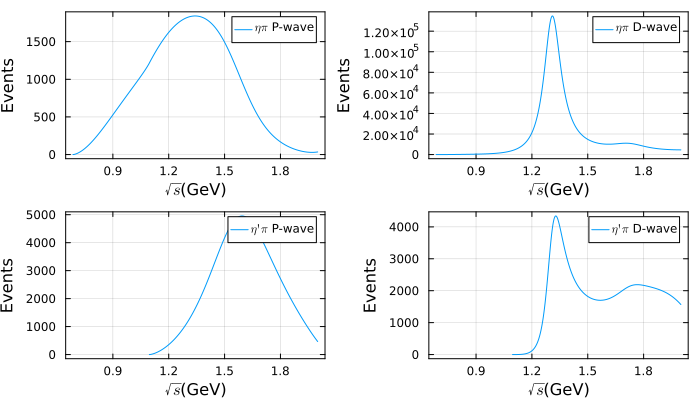

In [78]:
let Ev=collect((mpi+meta):0.001:2.0)
    resv1=intesity_P.(Ev .^2)
    resv2=intesity_D.(Ev .^2)
    plt1=plot(Ev,[resv1[i][1] for i in eachindex(resv1)],xlabel=L"$\sqrt{s}$(GeV)",ylabel="Events",label=L"$\eta\pi$ P-wave")
    plt2=plot(Ev,[resv2[i][1] for i in eachindex(resv2)],xlabel=L"$\sqrt{s}$(GeV)",ylabel="Events",label=L"$\eta\pi$ D-wave")
    plt3=plot(Ev,[Ev[i]>(mpi+metap) ? resv1[i][2] : NaN for i in eachindex(resv1)]
        ,xlabel=L"$\sqrt{s}$(GeV)",ylabel="Events",label=L"$\eta'\pi$ P-wave")
    plt4=plot(Ev,[Ev[i]>(mpi+metap) ? resv2[i][2] : NaN for i in eachindex(resv2)]
        ,xlabel=L"$\sqrt{s}$(GeV)",ylabel="Events",label=L"$\eta'\pi$ D-wave")
    plot(plt1,plt2,plt3,plt4,layout=(2,2),size=(700,400))
end

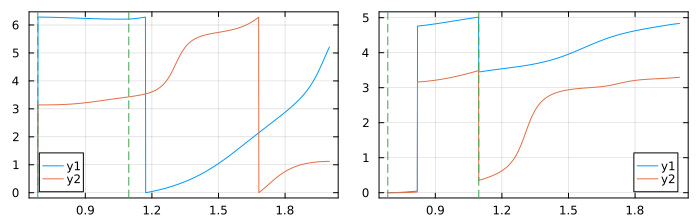

In [80]:
let Ev=collect((mpi+meta):0.001:2.0)
    res1=[amp1(E^2) for E in Ev]
    res2=[amp2(E^2) for E in Ev]

    plt1=plot(Ev,xangle.([res1[i][1] for i in eachindex(res1)]))
    plot!(Ev,xangle.([res2[i][1] for i in eachindex(res1)]))
    vline!([mpi+meta,mpi+metap],ls=:dash,label=false)
    plt2=plot(Ev,xangle.([res1[i][2] for i in eachindex(res1)]))
    plot!(Ev,xangle.([res2[i][2] for i in eachindex(res1)]))
    vline!([mpi+meta,mpi+metap],ls=:dash,label=false)
    plot(plt1,plt2,layout=(1,2),size=(700,220))
end

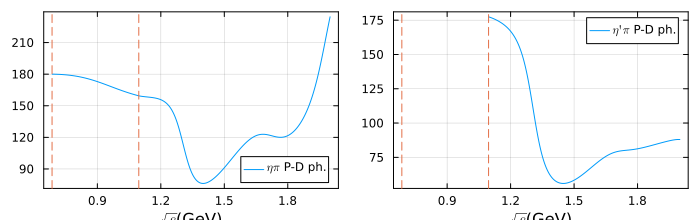

In [92]:
# manually adjusting
let Ev=collect((mpi+meta+0.001):0.001:2.0)
    res1=[xangle.(amp1(E^2)) for E in Ev]
    res2=[xangle.(amp2(E^2)) for E in Ev]

    ϕηπ_P=[Ev[i]<1.2&&res1[i][1]>π ? res1[i][1]-2π : res1[i][1] for i in eachindex(Ev)]
    ϕηπp_P=[Ev[i]<(mpi+metap) ? NaN : res1[i][2] for i in eachindex(Ev)]
    ϕηπ_D=[Ev[i]<1.8&&res2[i][1]>π ? res2[i][1]-2π : res2[i][1] for i in eachindex(Ev)]
    ϕηπp_D=[Ev[i]<(mpi+metap) ? NaN : res2[i][2] for i in eachindex(Ev)]

    plt1=plot(Ev,(ϕηπ_P .-ϕηπ_D)/π*180,label=L"$\eta\pi$ P-D ph.",xlabel=L"$\sqrt{s}$(GeV)")
    vline!([mpi+meta,mpi+metap],ls=:dash,label=false)
    plt2=plot(Ev,(ϕηπp_P .-ϕηπp_D)/π*180,label=L"$\eta'\pi$ P-D ph.",xlabel=L"$\sqrt{s}$(GeV)")
    vline!([mpi+meta,mpi+metap],ls=:dash,label=false)
    plot(plt1,plt2,layout=(1,2),size=(700,220))
end